In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('JNJ','XOM'), 
         ('JNJ','CVX'), 
         ('JNJ','ABBV'), 
         ('MCK','XOM'), 
         ('MCK', 'CVX'),
         ('MCK', 'ABBV'), 
         ('CSCO','XOM'), 
         ('CSCO', 'CVX'), 
         ('CSCO','ABBV')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

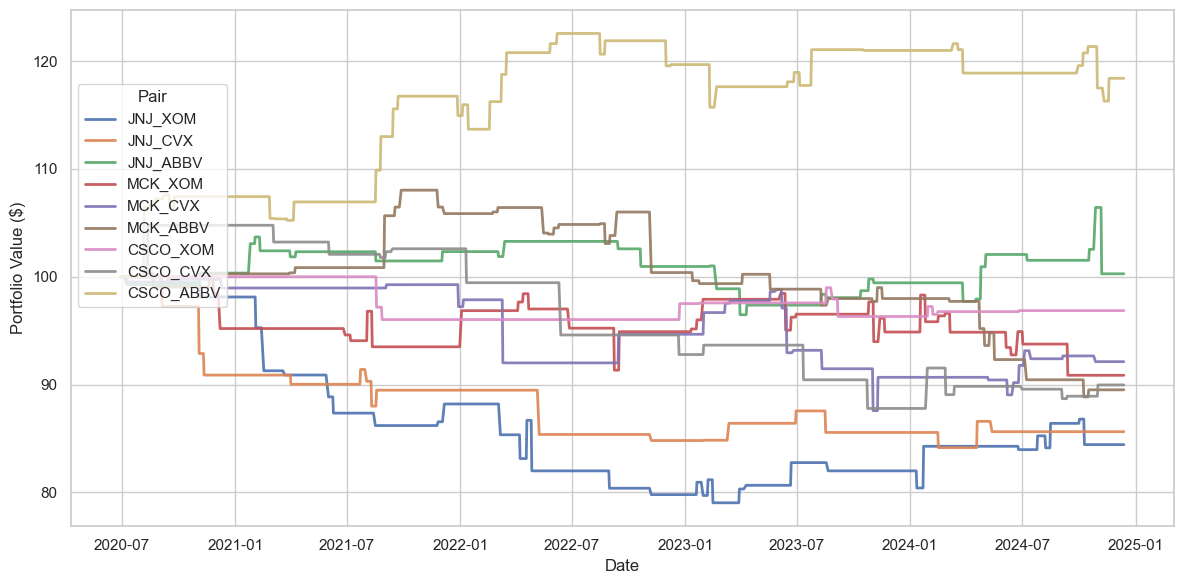

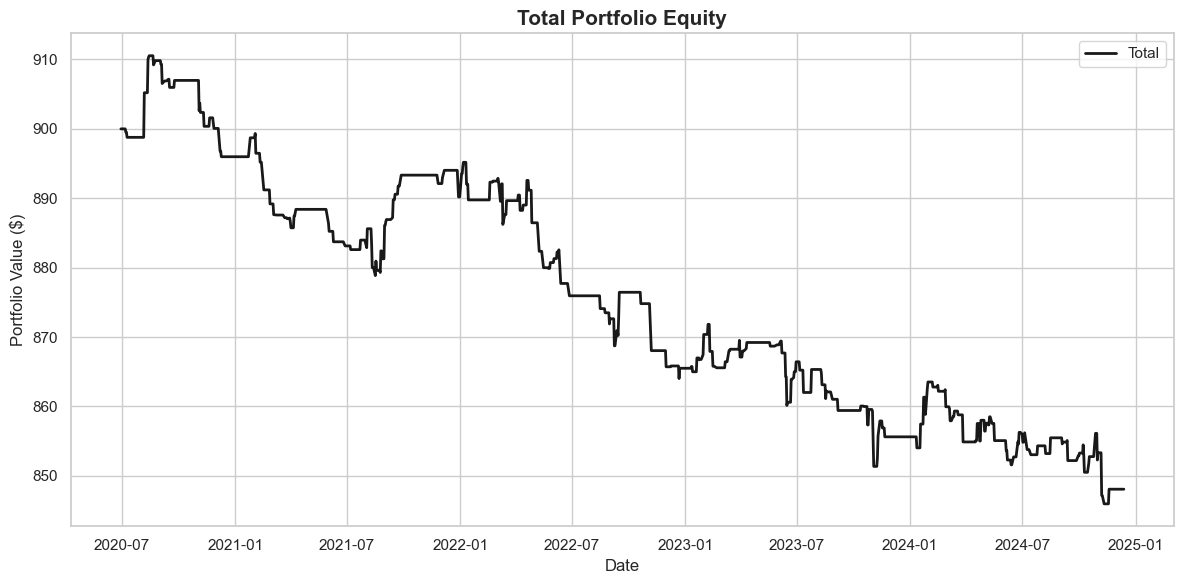

Summary
JNJ_XOM: Final Value = $84.43, Total Return = -15.57%, Trades = 32
JNJ_CVX: Final Value = $85.63, Total Return = -14.37%, Trades = 17
JNJ_ABBV: Final Value = $100.28, Total Return = 0.28%, Trades = 30
MCK_XOM: Final Value = $90.86, Total Return = -9.14%, Trades = 34
MCK_CVX: Final Value = $92.13, Total Return = -7.87%, Trades = 28
MCK_ABBV: Final Value = $89.52, Total Return = -10.48%, Trades = 38
CSCO_XOM: Final Value = $96.86, Total Return = -3.14%, Trades = 11
CSCO_CVX: Final Value = $89.97, Total Return = -10.03%, Trades = 19
CSCO_ABBV: Final Value = $118.41, Total Return = 18.41%, Trades = 42

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $848.08
Total Return:            -5.77%

Sharpe Ratios
JNJ_XOM: Sharpe Ratio = -0.56
JNJ_CVX: Sharpe Ratio = -0.75
JNJ_ABBV: Sharpe Ratio = 0.04
MCK_XOM: Sharpe Ratio = -0.32
MCK_CVX: Sharpe Ratio = -0.33
MCK_ABBV: Sharpe Ratio = -0.48
CSCO_XOM: Sharpe Ratio = -0.33
CSCO_CVX: Sharpe Ratio = -0.44
CS

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)